<a href="https://colab.research.google.com/github/juhee0528-lang/0528/blob/main/%EB%9E%9C%EB%94%A9%ED%81%B4%EB%9F%BD_%EA%B0%9C%EB%B3%84_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 라이브러리

In [1]:
!pip install -q lightgbm

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from lightgbm import LGBMClassifier

RANDOM_STATE = 42

2. 데이터

In [3]:
df = pd.read_csv(
    "lending_club_2020_train.csv",
    low_memory=False
)

print("Data shape:", df.shape)
df.head()

Data shape: (1755295, 141)


,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,124989905,6000.0,6000.0,6000.0,36 months,7.97%,187.94,A,A5,Teacher,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,139665484,35000.0,35000.0,35000.0,60 months,14.47%,822.95,C,C2,Product Specialist,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,84253847,23200.0,23200.0,23200.0,60 months,24.99%,680.82,E,E4,Production Foreman,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
3,126296074,4500.0,4500.0,4500.0,36 months,9.93%,145.06,B,B2,Office Manager,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,148913312,15000.0,15000.0,15000.0,36 months,16.40%,530.33,C,C4,Secretary,...,May-2020,Jul-2020,May-2020,2.0,0.0,ACTIVE,413.83,11025.25,54.62,N


3. 필수 변수 확인

In [4]:
required_columns = [
    "loan_status",
    "issue_d",
    "funded_amnt_inv",
    "total_pymnt_inv"
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Required columns are missing: {missing_required_columns}"
    )

print("All required columns are available.")

All required columns are available.


4. 대출 상태 확인

In [5]:
loan_status_counts = (
    df["loan_status"]
    .value_counts(dropna=False)
    .to_frame("count")
)

display(loan_status_counts)

,count
loan_status,
Fully Paid,898522
Current,618688
Charged Off,217366
Late (31-120 days),9840
In Grace Period,6049
Late (16-30 days),1620
Issued,1258
Does not meet the credit policy. Status:Fully Paid,1223
Does not meet the credit policy. Status:Charged Off,460


5. 타겟 변수 생성


default = 1: 부도 또는 손실 발생

default = 0: 정상 상환 완료

In [6]:
positive_values = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status: Charged Off"
]

negative_values = [
    "Fully Paid",
    "Does not meet the credit policy. Status: Fully Paid"
]

In [7]:
def build_target(
    data,
    status_column="loan_status",
    positive_statuses=None,
    negative_statuses=None
):
    result = data.copy()

    result["default"] = np.nan

    result.loc[
        result[status_column].isin(positive_statuses),
        "default"
    ] = 1

    result.loc[
        result[status_column].isin(negative_statuses),
        "default"
    ] = 0

    return result

In [9]:
target_check = pd.crosstab(
    df["loan_status"],
    df["default"],
    dropna=False
)

display(target_check)

default,0.0,1.0,NaN
loan_status,,,
Charged Off,0,217366,0
Current,0,0,618688
Default,0,268,0
Does not meet the credit policy. Status:Charged Off,0,0,460
Does not meet the credit policy. Status:Fully Paid,0,0,1223
Fully Paid,898522,0,0
In Grace Period,0,0,6049
Issued,0,0,1258
Late (16-30 days),0,0,1620


6. 결과가 확정되지 않은 대출 제거

In [10]:
rows_before = len(df)

df = df.dropna(subset=["default"]).copy()
df["default"] = df["default"].astype(int)

rows_after = len(df)

print("Rows before filtering:", rows_before)
print("Rows after filtering:", rows_after)
print("Removed unresolved loans:", rows_before - rows_after)

Rows before filtering: 1755295
Rows after filtering: 1116156
Removed unresolved loans: 639139


In [11]:
target_distribution = pd.DataFrame({
    "count": df["default"].value_counts(),
    "ratio": df["default"].value_counts(normalize=True)
})

display(target_distribution)

,count,ratio
default,,
0,898522,0.805015
1,217634,0.194985


7. 대출 실행 연도 생성

In [12]:
df["issue_date"] = pd.to_datetime(
    df["issue_d"],
    format="%b-%Y",
    errors="coerce"
)

In [13]:
print("Missing issue dates:", df["issue_date"].isna().sum())

display(
    df[["issue_d", "issue_date"]].head()
)

Missing issue dates: 0


,issue_d,issue_date
0,Dec-2017,2017-12-01
2,Jul-2016,2016-07-01
5,Oct-2017,2017-10-01
6,May-2017,2017-05-01
7,Sep-2015,2015-09-01


In [14]:
df["issue_year"] = df["issue_date"].dt.year

In [15]:
display(
    df["issue_year"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("count")
)

,count
issue_year,
2007,155
2008,941
2009,2815
2010,6856
2011,12985
2012,32046
2013,81069
2014,140952
2015,241970


8. 대출별 수익률 계산

In [16]:
def add_loan_return(data):
    result = data.copy()

    valid_investment = (
        result["funded_amnt_inv"].notna()
        & result["total_pymnt_inv"].notna()
        & (result["funded_amnt_inv"] > 0)
    )

    result["loan_return"] = np.nan

    result.loc[
        valid_investment,
        "loan_return"
    ] = (
        result.loc[valid_investment, "total_pymnt_inv"]
        - result.loc[valid_investment, "funded_amnt_inv"]
    ) / result.loc[valid_investment, "funded_amnt_inv"]

    return result

In [17]:
df = add_loan_return(df)

In [18]:
rows_before_return_filter = len(df)

df = df.dropna(
    subset=["loan_return", "issue_year"]
).copy()

print(
    "Removed rows without return or year:",
    rows_before_return_filter - len(df)
)

Removed rows without return or year: 70


In [19]:
display(df["loan_return"].describe())

,loan_return
count,1.116086e+06
mean,4.528343e-02
std,2.879675e-01
min,-1.000000e+00
25%,4.040000e-02
50%,1.166659e-01
75%,1.921253e-01
max,1.170300e+00


9. 연도 기준 데이터 분리

In [20]:
train_df = df[
    df["issue_year"] <= 2014
].copy()

val_df = df[
    df["issue_year"] == 2015
].copy()

test_df = df[
    df["issue_year"] == 2016
].copy()

In [21]:
split_summary = pd.DataFrame({
    "dataset": ["Train", "Validation", "Test"],
    "period": ["2014 and earlier", "2015", "2016"],
    "rows": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "default_rate": [
        train_df["default"].mean(),
        val_df["default"].mean(),
        test_df["default"].mean()
    ],
    "mean_return": [
        train_df["loan_return"].mean(),
        val_df["loan_return"].mean(),
        test_df["loan_return"].mean()
    ]
})

display(split_summary)

,dataset,period,rows,default_rate,mean_return
0,Train,2014 and earlier,277749,0.166226,0.116373
1,Validation,2015,241970,0.197008,0.067735
2,Test,2016,242270,0.196475,0.050204


In [22]:
if train_df.empty:
    raise ValueError("Train data is empty.")

if val_df.empty:
    raise ValueError("Validation data for 2015 is empty.")

if test_df.empty:
    raise ValueError("Test data for 2016 is empty.")

10. 모델 제거할 변수


In [23]:
target_columns = [
    "default",
    "loan_status"
]

return_columns = [
    "loan_return",
    "funded_amnt_inv",
    "total_pymnt_inv"
]

leakage_columns = [
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d",
    "last_fico_range_high",
    "last_fico_range_low",

    "hardship_flag",
    "hardship_type",
    "hardship_reason",
    "hardship_status",
    "deferral_term",
    "hardship_amount",
    "hardship_start_date",
    "hardship_end_date",
    "payment_plan_start_date",
    "hardship_length",
    "hardship_dpd",
    "hardship_loan_status",
    "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount",
    "hardship_last_payment_amount",

    "debt_settlement_flag",
    "debt_settlement_flag_date",
    "settlement_status",
    "settlement_date",
    "settlement_amount",
    "settlement_percentage",
    "settlement_term"
]

identifier_columns = [
    "id",
    "member_id",
    "url"
]

free_text_columns = [
    "title",
    "desc",
    "emp_title"
]

raw_date_columns = [
    "issue_d",
    "issue_date",
    "earliest_cr_line"
]

team_removed_columns = [
    "initial_list_status",
    "policy_code",
    "pymnt_plan",
    "disbursement_method"
]

In [24]:
drop_columns = sorted(
    set(
        target_columns
        + return_columns
        + leakage_columns
        + identifier_columns
        + free_text_columns
        + raw_date_columns
        + team_removed_columns
    )
)

existing_drop_columns = [
    column
    for column in drop_columns
    if column in df.columns
]

print("Number of columns removed from model:", len(existing_drop_columns))
print(existing_drop_columns)

Number of columns removed from model: 45
['collection_recovery_fee', 'debt_settlement_flag', 'default', 'deferral_term', 'earliest_cr_line', 'emp_title', 'funded_amnt_inv', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_flag', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'id', 'initial_list_status', 'issue_d', 'issue_date', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'loan_return', 'loan_status', 'next_pymnt_d', 'orig_projected_additional_accrued_interest', 'out_prncp', 'out_prncp_inv', 'payment_plan_start_date', 'policy_code', 'pymnt_plan', 'recoveries', 'title', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_late_fee', 'total_rec_prncp', 'url']


11. 모델 입력과 타겟 생성

In [25]:
X_train = train_df.drop(
    columns=existing_drop_columns,
    errors="ignore"
).copy()

X_val = val_df.drop(
    columns=existing_drop_columns,
    errors="ignore"
).copy()

X_test = test_df.drop(
    columns=existing_drop_columns,
    errors="ignore"
).copy()

y_train = train_df["default"].copy()
y_val = val_df["default"].copy()
y_test = test_df["default"].copy()

In [26]:
common_columns = (
    X_train.columns
    .intersection(X_val.columns)
    .intersection(X_test.columns)
)

X_train = X_train[common_columns].copy()
X_val = X_val[common_columns].copy()
X_test = X_test[common_columns].copy()

print("Initial number of model features:", len(common_columns))

Initial number of model features: 100


12. 문자열 숫자 변수 변환

In [27]:
def convert_percentage_columns(data):
    result = data.copy()

    percentage_columns = [
        "int_rate",
        "revol_util"
    ]

    for column in percentage_columns:
        if column in result.columns:
            result[column] = (
                result[column]
                .astype(str)
                .str.replace("%", "", regex=False)
                .str.strip()
                .replace(
                    {
                        "nan": np.nan,
                        "None": np.nan,
                        "": np.nan
                    }
                )
            )

            result[column] = pd.to_numeric(
                result[column],
                errors="coerce"
            )

    return result

In [28]:
def convert_emp_length(data):
    result = data.copy()

    if "emp_length" not in result.columns:
        return result

    emp_length_mapping = {
        "< 1 year": 0,
        "1 year": 1,
        "2 years": 2,
        "3 years": 3,
        "4 years": 4,
        "5 years": 5,
        "6 years": 6,
        "7 years": 7,
        "8 years": 8,
        "9 years": 9,
        "10+ years": 10,
        "n/a": np.nan
    }

    result["emp_length"] = (
        result["emp_length"]
        .map(emp_length_mapping)
    )

    return result

In [29]:
for dataset_name in ["X_train", "X_val", "X_test"]:
    converted_data = convert_percentage_columns(
        globals()[dataset_name]
    )

    converted_data = convert_emp_length(
        converted_data
    )

    globals()[dataset_name] = converted_data

13. 결측률이 높은 변수 제거

In [30]:
missing_rates = X_train.isna().mean()

high_missing_columns = (
    missing_rates[
        missing_rates >= 0.80
    ]
    .index
    .tolist()
)

print("High-missing columns:", len(high_missing_columns))
print(high_missing_columns)

High-missing columns: 30
['mths_since_last_record', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med']


In [31]:
X_train = X_train.drop(
    columns=high_missing_columns,
    errors="ignore"
)

X_val = X_val.drop(
    columns=high_missing_columns,
    errors="ignore"
)

X_test = X_test.drop(
    columns=high_missing_columns,
    errors="ignore"
)

14. 상수 변수 제거

In [32]:
constant_columns = [
    column
    for column in X_train.columns
    if X_train[column].nunique(dropna=False) <= 1
]

print("Constant columns:", constant_columns)

Constant columns: ['application_type']


In [33]:
X_train = X_train.drop(
    columns=constant_columns,
    errors="ignore"
)

X_val = X_val.drop(
    columns=constant_columns,
    errors="ignore"
)

X_test = X_test.drop(
    columns=constant_columns,
    errors="ignore"
)

15. 범주 수가 너무 많은 변수 제거

In [34]:
temporary_categorical_columns = (
    X_train
    .select_dtypes(exclude=["number", "bool"])
    .columns
    .tolist()
)

high_cardinality_columns = [
    column
    for column in temporary_categorical_columns
    if X_train[column].nunique(dropna=True) > 100
]

print("High-cardinality columns:", high_cardinality_columns)

High-cardinality columns: ['zip_code']


In [35]:
X_train = X_train.drop(
    columns=high_cardinality_columns,
    errors="ignore"
)

X_val = X_val.drop(
    columns=high_cardinality_columns,
    errors="ignore"
)

X_test = X_test.drop(
    columns=high_cardinality_columns,
    errors="ignore"
)

16. 최종 변수 검증

In [36]:
assert list(X_train.columns) == list(X_val.columns)
assert list(X_train.columns) == list(X_test.columns)

In [37]:
remaining_leakage_columns = [
    column
    for column in leakage_columns
    if column in X_train.columns
]

print("Remaining leakage columns:", remaining_leakage_columns)

if remaining_leakage_columns:
    raise ValueError(
        f"Leakage columns remain: {remaining_leakage_columns}"
    )

Remaining leakage columns: []


In [38]:
print("Final number of model features:", X_train.shape[1])
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Final number of model features: 68
Train shape: (277749, 68)
Validation shape: (241970, 68)
Test shape: (242270, 68)


In [39]:
model_feature_table = pd.DataFrame({
    "feature": X_train.columns,
    "dtype": X_train.dtypes.astype(str).values,
    "missing_rate": X_train.isna().mean().values
})

display(model_feature_table)

,feature,dtype,missing_rate
0,loan_amnt,float64,0.000000
1,funded_amnt,float64,0.000000
2,term,object,0.000000
3,int_rate,float64,0.000000
4,installment,float64,0.000000
...,...,...,...
63,tot_hi_cred_lim,float64,0.145217
64,total_bal_ex_mort,float64,0.101642
65,total_bc_limit,float64,0.101642
66,total_il_high_credit_limit,float64,0.145217


17. 숫자형·범주형 변수 구분

In [40]:
numeric_columns = (
    X_train
    .select_dtypes(include=["number", "bool"])
    .columns
    .tolist()
)

categorical_columns = (
    X_train
    .select_dtypes(exclude=["number", "bool"])
    .columns
    .tolist()
)

print("Numeric features:", len(numeric_columns))
print("Categorical features:", len(categorical_columns))

Numeric features: 61
Categorical features: 7


18. 전처리 파이프라인

In [41]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [42]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=20
            )
        )
    ]
)

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ],
    remainder="drop"
)

19. 모델 정의

In [44]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=12,
                    min_samples_leaf=20,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    ),

    "LightGBM": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                LGBMClassifier(
                    n_estimators=500,
                    learning_rate=0.03,
                    num_leaves=31,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbosity=-1
                )
            )
        ]
    )
}

20. 모델 학습 및 검증 확률 생성

In [45]:
fitted_models = {}
validation_predictions = {}
validation_auc_results = []

In [46]:
for model_name, model in models.items():
    print(f"Training: {model_name}")

    model.fit(
        X_train,
        y_train
    )

    val_probability = model.predict_proba(
        X_val
    )[:, 1]

    val_auc = roc_auc_score(
        y_val,
        val_probability
    )

    fitted_models[model_name] = model
    validation_predictions[model_name] = val_probability

    validation_auc_results.append({
        "model": model_name,
        "validation_auc": val_auc
    })

    print(f"Validation AUC: {val_auc:.4f}")
    print("-" * 50)

Training: Logistic Regression
Validation AUC: 0.7235
--------------------------------------------------
Training: Random Forest
Validation AUC: 0.7222
--------------------------------------------------
Training: LightGBM
Validation AUC: 0.7277
--------------------------------------------------


In [47]:
validation_auc_df = pd.DataFrame(
    validation_auc_results
).sort_values(
    "validation_auc",
    ascending=False
)

display(validation_auc_df)

,model,validation_auc
2,LightGBM,0.727695
0,Logistic Regression,0.723473
1,Random Forest,0.722212


In [48]:
for model_name, probabilities in validation_predictions.items():
    print(model_name)
    print(probabilities[:10])
    print()

Logistic Regression
[0.40625702 0.55226053 0.70806872 0.75144006 0.57335088 0.14081136
 0.64123826 0.23805986 0.42440284 0.43912744]

Random Forest
[0.41467802 0.48175665 0.65568166 0.57228939 0.55760282 0.30499265
 0.5699155  0.27291375 0.3558064  0.42395074]

LightGBM
[0.39735947 0.46609945 0.65326387 0.72412513 0.55185854 0.30792019
 0.66918634 0.27027503 0.33767969 0.36964029]



21. Sharpe Ratio 계산

In [49]:
def calculate_sharpe_ratio(
    returns,
    risk_free_rate=0.0
):
    valid_returns = pd.Series(
        returns
    ).dropna()

    if len(valid_returns) < 2:
        return np.nan

    return_std = valid_returns.std(ddof=1)

    if (
        pd.isna(return_std)
        or np.isclose(return_std, 0)
    ):
        return np.nan

    return (
        valid_returns.mean() - risk_free_rate
    ) / return_std

22. 임계값별 평가 함수

In [50]:
def evaluate_thresholds(
    probabilities,
    evaluation_df,
    thresholds,
    risk_free_rate=0.0,
    minimum_approval_rate=0.10,
    minimum_loans=100
):
    probabilities = np.asarray(probabilities)

    if len(probabilities) != len(evaluation_df):
        raise ValueError(
            "Probability length and evaluation data length do not match."
        )

    results = []

    for threshold in thresholds:
        approved_mask = probabilities < threshold

        approved_data = evaluation_df.loc[
            approved_mask
        ].copy()

        approved_loans = len(approved_data)
        approval_rate = approved_loans / len(evaluation_df)

        if approved_loans < minimum_loans:
            continue

        if approval_rate < minimum_approval_rate:
            continue

        portfolio_returns = approved_data["loan_return"]

        results.append({
            "threshold": threshold,
            "approved_loans": approved_loans,
            "approval_rate": approval_rate,
            "rejected_loans": len(evaluation_df) - approved_loans,
            "default_rate": approved_data["default"].mean(),
            "mean_return": portfolio_returns.mean(),
            "return_std": portfolio_returns.std(ddof=1),
            "sharpe_ratio": calculate_sharpe_ratio(
                portfolio_returns,
                risk_free_rate=risk_free_rate
            )
        })

    return pd.DataFrame(results)

23. Validation 데이터에서 최적 임계값 탐색

In [51]:
thresholds = np.arange(
    0.01,
    0.51,
    0.01
)

validation_threshold_results = {}
best_thresholds = {}

In [52]:
for model_name, probabilities in validation_predictions.items():
    result = evaluate_thresholds(
        probabilities=probabilities,
        evaluation_df=val_df,
        thresholds=thresholds,
        risk_free_rate=0.0,
        minimum_approval_rate=0.10,
        minimum_loans=100
    )

    validation_threshold_results[model_name] = result

    if result.empty:
        print(f"No valid threshold found for {model_name}")
        continue

    valid_result = result.dropna(
        subset=["sharpe_ratio"]
    )

    if valid_result.empty:
        print(f"No valid Sharpe Ratio found for {model_name}")
        continue

    best_row = valid_result.loc[
        valid_result["sharpe_ratio"].idxmax()
    ]

    best_thresholds[model_name] = float(
        best_row["threshold"]
    )

    print(f"Model: {model_name}")
    display(best_row.to_frame().T)

Model: Logistic Regression


,threshold,approved_loans,approval_rate,rejected_loans,default_rate,mean_return,return_std,sharpe_ratio
0,0.22,25896.0,0.107022,216074.0,0.036299,0.075449,0.102203,0.738229


Model: Random Forest


,threshold,approved_loans,approval_rate,rejected_loans,default_rate,mean_return,return_std,sharpe_ratio
0,0.23,25186.0,0.104087,216784.0,0.034106,0.073313,0.095628,0.766647


Model: LightGBM


,threshold,approved_loans,approval_rate,rejected_loans,default_rate,mean_return,return_std,sharpe_ratio
0,0.19,26497.0,0.109505,215473.0,0.032796,0.07621,0.09593,0.794427


24. 임계값별 Sharpe Ratio 시각화

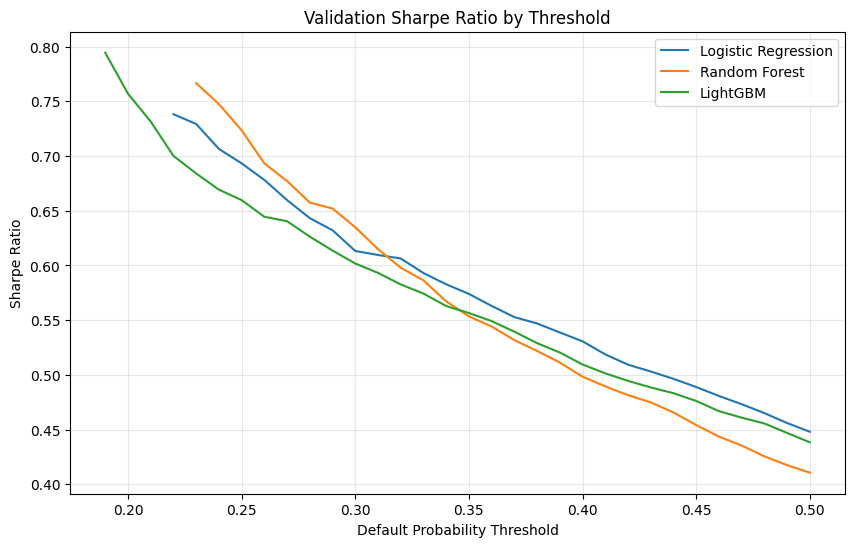

In [53]:
plt.figure(figsize=(10, 6))

for model_name, result in validation_threshold_results.items():
    if result.empty:
        continue

    plt.plot(
        result["threshold"],
        result["sharpe_ratio"],
        label=model_name
    )

plt.xlabel("Default Probability Threshold")
plt.ylabel("Sharpe Ratio")
plt.title("Validation Sharpe Ratio by Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

25. Test 데이터 최종 평가

In [54]:
test_results = []
test_probabilities = {}

In [55]:
for model_name, model in fitted_models.items():
    if model_name not in best_thresholds:
        continue

    test_probability = model.predict_proba(
        X_test
    )[:, 1]

    test_probabilities[model_name] = test_probability

    threshold = best_thresholds[model_name]

    approved_mask = (
        test_probability < threshold
    )

    approved_test = test_df.loc[
        approved_mask
    ].copy()

    if len(approved_test) < 2:
        continue

    test_auc = roc_auc_score(
        y_test,
        test_probability
    )

    test_results.append({
        "model": model_name,
        "threshold": threshold,
        "test_auc": test_auc,
        "approved_loans": len(approved_test),
        "approval_rate": len(approved_test) / len(test_df),
        "rejected_loans": len(test_df) - len(approved_test),
        "default_rate": approved_test["default"].mean(),
        "mean_return": approved_test["loan_return"].mean(),
        "return_std": approved_test["loan_return"].std(ddof=1),
        "sharpe_ratio": calculate_sharpe_ratio(
            approved_test["loan_return"],
            risk_free_rate=0.0
        )
    })

In [56]:
test_result_df = pd.DataFrame(test_results)

if test_result_df.empty:
    raise ValueError(
        "No valid test results were generated."
    )

display(
    test_result_df.sort_values(
        "sharpe_ratio",
        ascending=False
    )
)

,model,threshold,test_auc,approved_loans,approval_rate,rejected_loans,default_rate,mean_return,return_std,sharpe_ratio
2,LightGBM,0.19,0.721136,26551,0.109593,215719,0.038530,0.067945,0.110191,0.616610
1,Random Forest,0.23,0.716412,26242,0.108317,216028,0.039402,0.065639,0.110803,0.592389
0,Logistic Regression,0.22,0.716585,27593,0.113894,214677,0.042982,0.067599,0.117162,0.576971


26. 전체 대출 비교

In [57]:
baseline_result = pd.DataFrame({
    "model": ["All Approved Loans"],
    "threshold": [np.nan],
    "test_auc": [np.nan],
    "approved_loans": [len(test_df)],
    "approval_rate": [1.0],
    "rejected_loans": [0],
    "default_rate": [test_df["default"].mean()],
    "mean_return": [test_df["loan_return"].mean()],
    "return_std": [test_df["loan_return"].std(ddof=1)],
    "sharpe_ratio": [
        calculate_sharpe_ratio(
            test_df["loan_return"],
            risk_free_rate=0.0
        )
    ]
})

In [58]:
final_comparison = pd.concat(
    [
        baseline_result,
        test_result_df
    ],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

display(final_comparison)

,model,threshold,test_auc,approved_loans,approval_rate,rejected_loans,default_rate,mean_return,return_std,sharpe_ratio
0,LightGBM,0.19,0.721136,26551,0.109593,215719,0.038530,0.067945,0.110191,0.616610
1,Random Forest,0.23,0.716412,26242,0.108317,216028,0.039402,0.065639,0.110803,0.592389
2,Logistic Regression,0.22,0.716585,27593,0.113894,214677,0.042982,0.067599,0.117162,0.576971
3,All Approved Loans,NaN,NaN,242270,1.000000,0,0.196475,0.050204,0.268823,0.186754


27. 최종 모델 확인

In [59]:
best_model_result = (
    test_result_df
    .dropna(subset=["sharpe_ratio"])
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .iloc[0]
)

best_model_name = best_model_result["model"]
best_threshold = best_model_result["threshold"]

print("Best model:", best_model_name)
print("Best threshold:", best_threshold)
print("Test Sharpe Ratio:", best_model_result["sharpe_ratio"])
print("Approval rate:", best_model_result["approval_rate"])
print("Default rate:", best_model_result["default_rate"])

Best model: LightGBM
Best threshold: 0.19
Test Sharpe Ratio: 0.6166097969775919
Approval rate: 0.10959260329384571
Default rate: 0.0385296222364506


28. 기존 포트폴리오 대비 개선 효과

In [60]:
baseline_sharpe = baseline_result.loc[
    0,
    "sharpe_ratio"
]

baseline_default_rate = baseline_result.loc[
    0,
    "default_rate"
]

sharpe_improvement = (
    best_model_result["sharpe_ratio"]
    - baseline_sharpe
)

default_rate_reduction = (
    baseline_default_rate
    - best_model_result["default_rate"]
)

print("Baseline Sharpe Ratio:", baseline_sharpe)
print("Model Sharpe Ratio:", best_model_result["sharpe_ratio"])
print("Sharpe Ratio improvement:", sharpe_improvement)
print("Default rate reduction:", default_rate_reduction)

Baseline Sharpe Ratio: 0.1867543627068598
Model Sharpe Ratio: 0.6166097969775919
Sharpe Ratio improvement: 0.4298554342707321
Default rate reduction: 0.15794538498689525


29. 최종 모델 분류 결과

In [61]:
best_model = fitted_models[best_model_name]

best_test_probability = test_probabilities[
    best_model_name
]

best_test_prediction = (
    best_test_probability >= best_threshold
).astype(int)

In [62]:
print(
    classification_report(
        y_test,
        best_test_prediction,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9615    0.1311    0.2308    194670
           1     0.2159    0.9785    0.3538     47600

    accuracy                         0.2976    242270
   macro avg     0.5887    0.5548    0.2923    242270
weighted avg     0.8150    0.2976    0.2550    242270



In [63]:
confusion_matrix_df = pd.DataFrame(
    confusion_matrix(
        y_test,
        best_test_prediction
    ),
    index=[
        "Actual Non-default",
        "Actual Default"
    ],
    columns=[
        "Predicted Non-default",
        "Predicted Default"
    ]
)

display(confusion_matrix_df)

,Predicted Non-default,Predicted Default
Actual Non-default,25528,169142
Actual Default,1023,46577


30. 최종 결과 시각화

Sharpe Ratio 비교

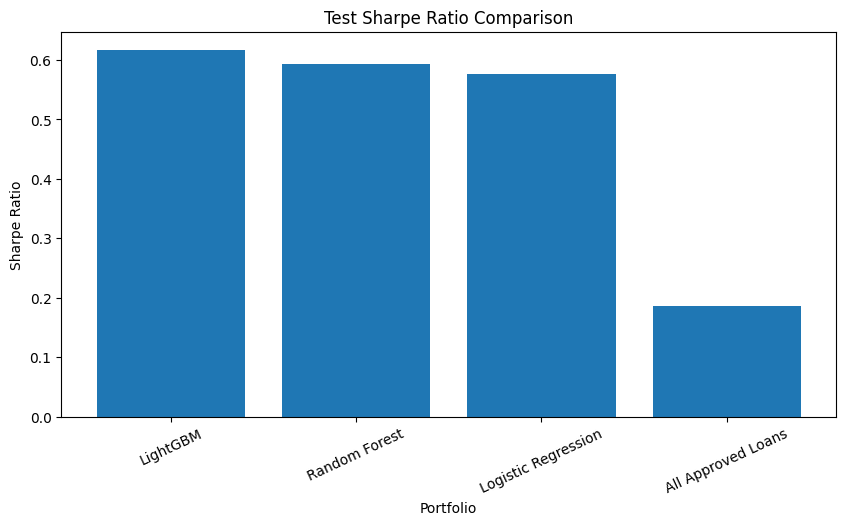

In [64]:
plot_data = final_comparison.sort_values(
    "sharpe_ratio",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.bar(
    plot_data["model"],
    plot_data["sharpe_ratio"]
)

plt.xlabel("Portfolio")
plt.ylabel("Sharpe Ratio")
plt.title("Test Sharpe Ratio Comparison")
plt.xticks(rotation=25)
plt.show()

부도율 비교

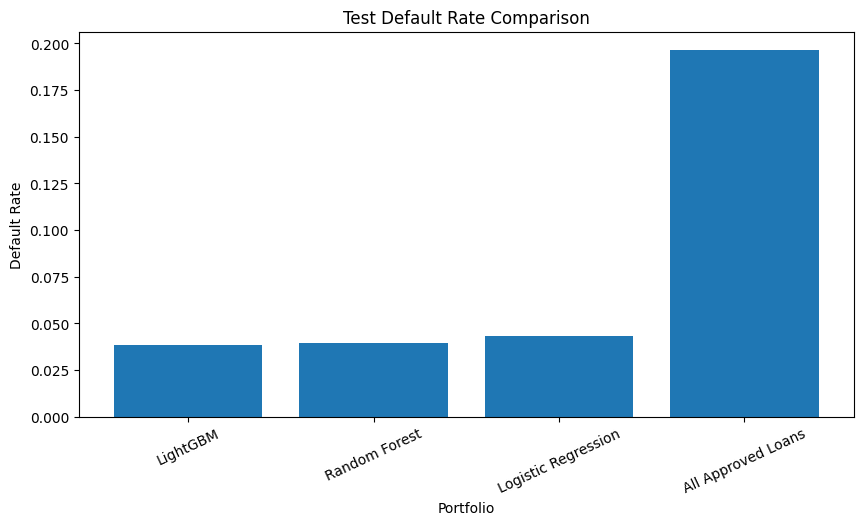

In [65]:
plt.figure(figsize=(10, 5))

plt.bar(
    plot_data["model"],
    plot_data["default_rate"]
)

plt.xlabel("Portfolio")
plt.ylabel("Default Rate")
plt.title("Test Default Rate Comparison")
plt.xticks(rotation=25)
plt.show()